# Analyse globale du dataset de brevets

Ce notebook charge le fichier CSV situe dans le dossier `data`, puis realise une premiere exploration globale : dimensions du dataset, informations de base, nombre de brevets par annee lorsque l'information est disponible, et repartition des pays lorsque le champ existe ou peut etre deduit des identifiants de brevet.

Le fichier pouvant etre volumineux, l'analyse se fait en lecture ligne par ligne afin d'eviter de charger tout le CSV en memoire.

## 1. Chargement et analyse en flux

In [1]:
from collections import Counter
from datetime import datetime
from pathlib import Path
import csv
import sys

DATA_PATH_CANDIDATES = [
    Path("../data/patent_analysis_data.csv"),
    Path("data/patent_analysis_data.csv"),
]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])

# Certaines colonnes texte peuvent etre tres longues dans les brevets.
field_size_limit = sys.maxsize
while True:
    try:
        csv.field_size_limit(field_size_limit)
        break
    except OverflowError:
        field_size_limit = field_size_limit // 10

UNIQUE_LIMIT_PER_COLUMN = 10_000
PREVIEW_LIMIT = 3

def find_column(columns, possible_names):
    normalized_columns = {column.strip().lower(): column for column in columns}
    for name in possible_names:
        if name.lower() in normalized_columns:
            return normalized_columns[name.lower()]
    return None

def extract_year(value):
    value = str(value or "").strip()
    if not value:
        return None
    if len(value) >= 4 and value[:4].isdigit():
        return value[:4]
    for date_format in ("%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y"):
        try:
            return str(datetime.strptime(value, date_format).year)
        except ValueError:
            pass
    return None

def truncate_value(value, limit=120):
    value = str(value or "")
    return value[:limit] + "..." if len(value) > limit else value

with DATA_PATH.open("r", encoding="utf-8", newline="") as csv_file:
    reader = csv.DictReader(csv_file)
    columns = reader.fieldnames or []

    row_count = 0
    preview_rows = []
    missing_counts = Counter()
    non_empty_counts = Counter()
    max_lengths = Counter()
    unique_values = {column: set() for column in columns}
    unique_over_limit = set()
    year_counts = Counter()
    country_counts = Counter()

    year_column = find_column(columns, ["year", "annee", "année", "publication year", "priority year"])
    date_column = None if year_column else find_column(columns, ["Publication Date", "Priority Date", "publication_date", "priority_date"])
    year_source = year_column or (f"annee deduite depuis {date_column}" if date_column else None)

    country_column = find_column(columns, ["country", "pays", "country code", "country_code", "jurisdiction"])
    patent_id_column = None if country_column else find_column(columns, ["Patent ID", "patent_id", "publication number", "publication_number"])
    country_source = country_column or (f"code deduit depuis {patent_id_column}" if patent_id_column else None)

    for row in reader:
        row_count += 1

        if len(preview_rows) < PREVIEW_LIMIT:
            preview_rows.append({column: truncate_value(row.get(column, "")) for column in columns})

        for column in columns:
            value = str(row.get(column, "") or "").strip()
            max_lengths[column] = max(max_lengths[column], len(value))

            if value:
                non_empty_counts[column] += 1
                if column not in unique_over_limit:
                    unique_values[column].add(value)
                    if len(unique_values[column]) > UNIQUE_LIMIT_PER_COLUMN:
                        unique_values[column].clear()
                        unique_over_limit.add(column)
            else:
                missing_counts[column] += 1

        if year_column:
            year = str(row.get(year_column, "") or "").strip()
        elif date_column:
            year = extract_year(row.get(date_column))
        else:
            year = None
        if year:
            year_counts[year] += 1

        if country_column:
            country = str(row.get(country_column, "") or "").strip().upper()
        elif patent_id_column:
            patent_id = str(row.get(patent_id_column, "") or "").strip().upper()
            prefix = patent_id.split("-", 1)[0]
            country = prefix if prefix.isalpha() and 2 <= len(prefix) <= 3 else None
        else:
            country = None
        if country:
            country_counts[country] += 1

print(f"Fichier charge : {DATA_PATH}")
print(f"Nombre de lignes : {row_count:,}".replace(",", " "))
print(f"Nombre de colonnes : {len(columns)}")

Fichier charge : ../data/patent_analysis_data.csv
Nombre de lignes : 23 339
Nombre de colonnes : 9


## 2. Informations de base

In [2]:
print("Colonnes disponibles :")
for index, column in enumerate(columns, start=1):
    print(f"{index}. {column}")

print("\nApercu des 3 premieres lignes :")
for row in preview_rows:
    print(row)

Colonnes disponibles :
1. Patent ID
2. Title
3. Assignee
4. Priority Date
5. Publication Date
6. Abstract
7. Claims
8. Description
9. Result Link

Apercu des 3 premieres lignes :
{'Patent ID': 'CN-110473636-B', 'Title': 'Intelligent medical advice recommendation method and system based on deep learning ', 'Assignee': '山东众阳健康科技集团有限公司', 'Priority Date': '2019-08-22', 'Publication Date': '2020-09-22', 'Abstract': 'The disclosure provides an intelligent medical advice recommendation method and system based on deep learning, and the i...', 'Claims': 'Claims (8)\n\n \n1. The intelligent medical advice recommendation method based on deep learning is characterized by compris...', 'Description': 'Description\n\nIntelligent medical advice recommendation method and system based on deep learning\n\nTechnical Field\nThe dis...', 'Result Link': 'https://patents.google.com/patent/CN110473636B/en'}
{'Patent ID': 'US-11850021-B2', 'Title': 'Dynamic self-learning medical image method and system ', 'Assi

In [ ]:
import matplotlib.pyplot as plt

# On suppose que missing_counts et row_count sont définis
if missing_counts:
    # 1. Préparation : Tri par nombre de valeurs manquantes (du plus grand au plus petit)
    # On transforme le dictionnaire en liste de tuples triée
    sorted_missing = sorted(missing_counts.items(), key=lambda x: x[1], reverse=True)
    
    columns = [item[0] for item in sorted_missing]
    counts = [item[1] for item in sorted_missing]
    
    # Calcul des pourcentages pour l'affichage
    percentages = [(count / row_count * 100) if row_count else 0 for count in counts]

    # 2. Création du graphique
    plt.figure(figsize=(10, 6))
    bars = plt.barh(columns, counts, color='salmon', edgecolor='black')

    # 3. Personnalisation
    plt.title("Top des colonnes avec le plus de valeurs manquantes")
    plt.xlabel("Nombre de valeurs manquantes")
    plt.ylabel("Colonnes")
    plt.gca().invert_yaxis() # Met la valeur la plus grande (le 'top') en haut
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Ajout des pourcentages au bout des barres pour plus de clarté
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + (max(counts) * 0.01), 
                 bar.get_y() + bar.get_height()/2, 
                 f"{percentages[i]:.1f}%", 
                 va='center', fontsize=9)

    plt.tight_layout()

    # 4. Sauvegarde
    plt.savefig("top_valeurs_manquantes.png")
    print("Graphique sauvegardé sous 'top_valeurs_manquantes.png'")
else:
    print("Aucune donnée manquante détectée.")

Qualite des donnees par colonne :
- Patent ID: > 10 000 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 18 caracteres
- Title: > 10 000 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 596 caracteres
- Assignee: 8 538 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 349 caracteres
- Priority Date: 4 115 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 10 caracteres
- Publication Date: 2 268 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 10 caracteres
- Abstract: > 10 000 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 3 419 caracteres
- Claims: > 10 000 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 186 717 caracteres
- Description: > 10 000 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 5 954 150 caracteres
- Result Link: > 10 000 valeurs uniques  0 valeurs manquantes (0.00%)  longueur max 53 caracteres


## 3. Nombre de brevets par annee

Graphique sauvegardé sous 'nombre_brevets_par_annee.png'


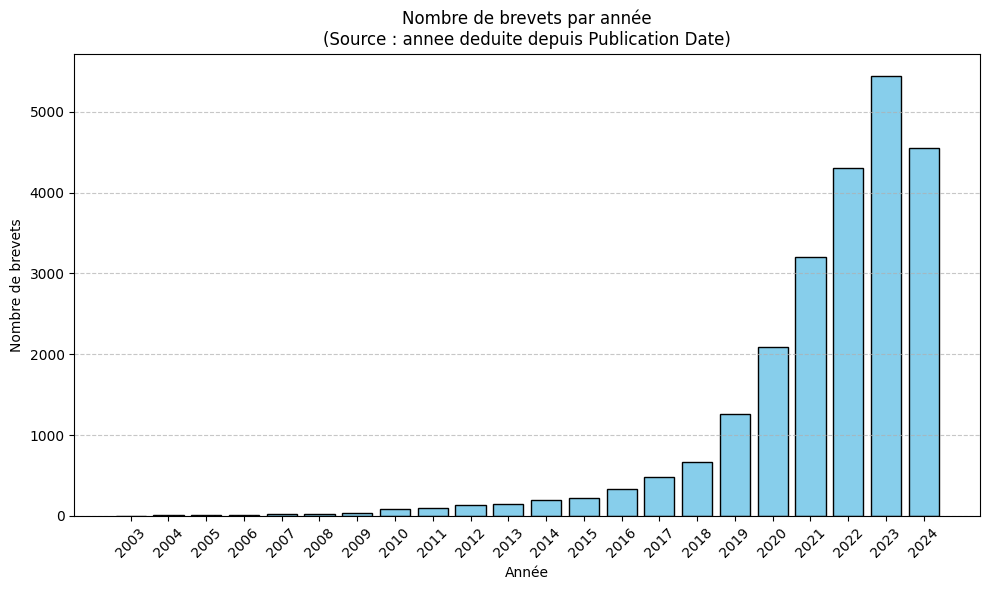

In [6]:
import matplotlib.pyplot as plt

if year_counts:
    # 1. Préparation des données triées
    sorted_data = sorted(year_counts.items())
    years = [str(item[0]) for item in sorted_data] # Conversion en string pour l'axe x
    counts = [item[1] for item in sorted_data]

    # 2. Création du graphique
    plt.figure(figsize=(10, 6))
    plt.bar(years, counts, color='skyblue', edgecolor='black')

    # 3. Personnalisation
    plt.title(f"Nombre de brevets par année\n(Source : {year_source})")
    plt.xlabel("Année")
    plt.ylabel("Nombre de brevets")
    plt.xticks(rotation=45) # Rotation pour éviter le chevauchement si beaucoup d'années
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajustement automatique pour ne pas couper les labels
    plt.tight_layout()

    # 4. Sauvegarde du graphique
    plt.savefig("nombre_brevets_par_annee.png")
    print("Graphique sauvegardé sous 'nombre_brevets_par_annee.png'")
else:
    print("Aucun champ année/date exploitable n'a été trouvé dans le dataset.")

## 4. Repartition des pays

Graphique sauvegardé sous 'repartition_pays.png'


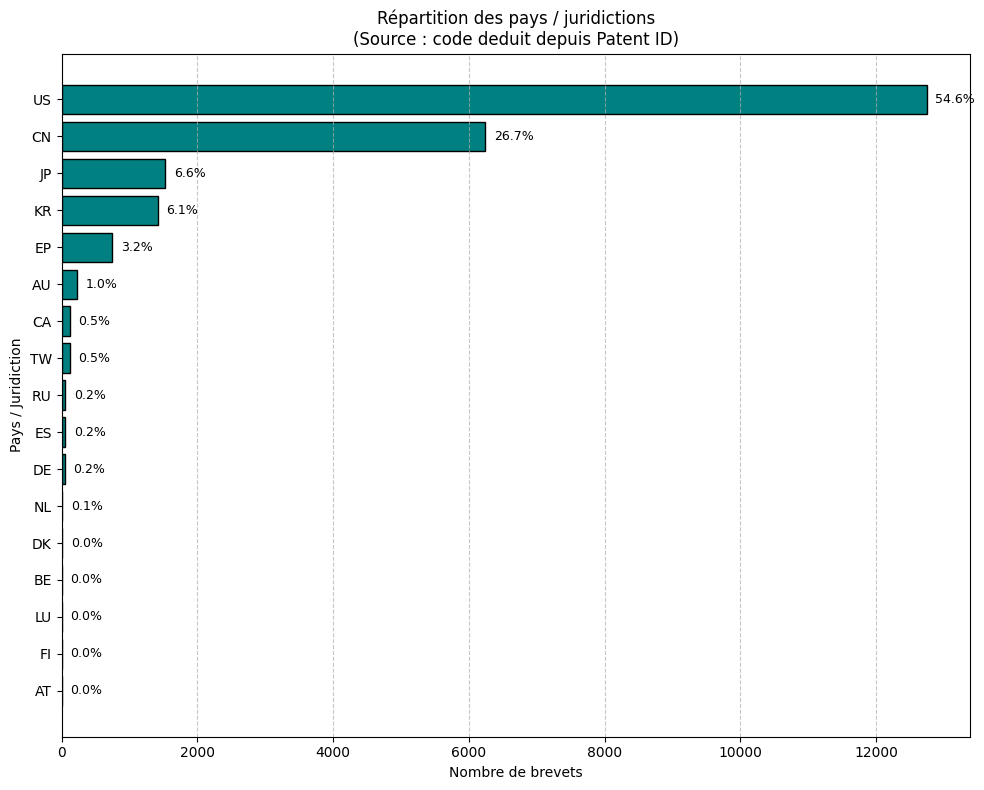

In [7]:
import matplotlib.pyplot as plt

# On suppose que country_counts et row_count sont déjà définis
if country_counts:
    # 1. Préparation des données
    # most_common() renvoie les éléments triés du plus grand au plus petit
    # On inverse la liste [::-1] pour que le plus grand apparaisse en haut du graphique
    data = country_counts.most_common()[::-1]
    countries = [item[0] for item in data]
    counts = [item[1] for item in data]
    
    # 2. Création du graphique
    plt.figure(figsize=(10, 8)) # Taille ajustée pour laisser de la place aux noms des pays
    plt.barh(countries, counts, color='teal', edgecolor='black')
    
    # 3. Personnalisation
    plt.title(f"Répartition des pays / juridictions\n(Source : {country_source})")
    plt.xlabel("Nombre de brevets")
    plt.ylabel("Pays / Juridiction")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Ajout des pourcentages sur le côté des barres (optionnel mais très utile)
    for i, v in enumerate(counts):
        percentage = (v / row_count * 100) if row_count else 0
        plt.text(v + (max(counts) * 0.01), i, f"{percentage:.1f}%", va='center', fontsize=9)
    
    plt.tight_layout()

    # 4. Sauvegarde
    plt.savefig("repartition_pays.png")
    print("Graphique sauvegardé sous 'repartition_pays.png'")
else:
    print("Aucun champ pays n'a été trouvé, et aucun code pays n'a pu être déduit des identifiants de brevet.")